# Reinforcement Learning Tarea 1 - K Armed Bandits

## Objetivos
- Demostrar entendimiento sobre K-Armed Bandits
- Implementar varios algoritmos vistos en el curso teórico 
- comparar su performance en un mismo problema (ambiente).

## A entregar
- Implementación de agente arbitrario.
- Implementación de agente epsilon-greedy.
- Implementación de agente epsilon-greedy optimista.
- Implementación de agente upper confidence bound.
- Grafique la evolución de las recompensas (reward) a lo largo del tiempo para cada algoritmo, promediado sobre 2000 ejecuciones.
- Escriba un reporte sobre sus implementaciones comparando los distintos agentes implementados.
- [Extra] Implementación de epsilon-greedy con decay.

## Descripción del ambiente a usar

Vamos a usar KBanditsEnv, un ambiente implementado con [Gymnasium](https://gymnasium.farama.org/index.html) pero orientada a [Armed Bandits](https://en.wikipedia.org/wiki/Multi-armed_bandit). 

Recordando el teórico, sabemos que un K Armed Bandit representa una maquina tragamonedas con multiples brazos (K) y donde nuestra recompensa depende de cual brazo tiremos.

En este caso particular, `k_bandits_env/KBanditsGaussian-v0` es el ambiente a utilizar (página 28 del libro de Sutton y Barto), cuenta con 10 brazos (K=10) y por cada interaccion con el ambiente (`step`) nustra recompensa (reward) depende de que brazo elegimos entre los 10 posibles. En este ambiente, todos los brazos tienen una recompensa (que puede ser negativa en algunos casos) y nuestro objetivo es diseñar agentes que maximicen la suma total de recompensas a lo largo de 1000 interacciones con el ambiente (`1000 steps`).

![KBandits](https://miro.medium.com/v2/resize:fit:720/format:webp/1*iguhq3SaQd730c-TYI8QZA.png)

El valor verdadero ($q_*(a)$) de cada brazo es muestreado de una distribución normal con media 0 y varianza 1. La recompensa de cada brazo es muestreada de una distribución normal con media $q_*(a)$ y varianza 1.


> Nota: El agente no tiene acceso a los valores verdaderos de los brazos, solo puede interactuar con el ambiente, es decir, seleccionar un brazo y recibir una recompensa. Nosotros usaremos los valores verdaderos para comparar la performance de los distintos agentes.

Algunas preguntas:
- ¿Es un ambiente estacionario o no estacionario?

Los valores verdaderos \( q_*(a) \) se fijan al crear el ambiente (se muestrean una vez de \( N(0,1) \) por brazo) 
y en cada paso, la recompensa del brazo \( a \) es \( N(q_*(a), 1) \). 
Esa media no cambia con el tiempo: la distribución de recompensa de cada acción es la misma en todos los pasos.


- ¿Qué se espera de un agente que seleccione brazos de manera aleatoria en terminos de recompensa y % de veces que selecciona el mejor brazo?

En cada paso, la probabilidad de elegir el brazo óptimo es \( \frac{1}{K} = \frac{1}{10} \), 
ya que todas las acciones son equiprobables y, con recompensas continuas, casi siempre hay un único máximo.

## Definición del ambiente e imports necesarios

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

from Agent import Agent
from Utils import get_env, plot_agents_performance

Algunas constantes que vamos a usar:

In [2]:
NUM_STEPS = 1000
NUM_EPISODES = 2000

In [3]:
# creamos un entorno de ejemplo, con print_true_values podemos ver los valores verdaderos de las acciones
# PD: en teoria no deberiamos tener acceso a estos valores pero nos sirve para comparar
sample_env = get_env(print_true_values=True) 
print(sample_env.action_space)

True means (q*): [ 0.16517361 -0.15022918 -0.11216786 -2.28233652  0.39972473 -0.23393519
  0.78004506 -0.35790405  0.48022177 -1.28101382]
Discrete(10)


## Implementación de Agentes

En esta sección, exploraremos cómo crear agentes concretos heredando de la clase abstracta `Agent`. Esta clase base define la estructura y el comportamiento general que cualquier agente debe seguir al interactuar con un entorno, proporcionando un marco consistente para diversas estrategias de toma de decisiones.


**Pasos para Implementar un Agente Concreto**

1. **Definir el Constructor (`__init__`)**: Inicializa los atributos específicos del agente, incluyendo su nombre y cualquier parámetro adicional necesario para su estrategia particular.

2. **Implementar `reset_internal_state`**: Establece o reinicia las variables internas que el agente utiliza para rastrear información durante su interacción con el entorno.

3. **Implementar `select_action`**: Define la lógica que el agente emplea para seleccionar una acción basada en la observación actual, la información proporcionada por el entorno y el estado interno del agente.

4. **Implementar `update_internal_state`**: Actualiza el estado interno del agente en función de la nueva información obtenida tras ejecutar una acción, como la nueva observación y la recompensa recibida.

5. **Implementar `get_extra_info`**: Proporciona información adicional sobre el estado o desempeño del agente, útil para análisis o depuración.


Preguntas que pueden ayudar a guiar la implementación de los agentes:
- ¿Qué información necesita el agente para tomar decisiones?
- ¿Cómo se actualiza el estado interno del agente después de cada interacción con el entorno?
- ¿Qué estrategias de selección de acciones basados en el conocimiento previo y la información actual se pueden utilizar?

**Evaluación del Desempeño de los Agentes**

Para analizar cómo se comportan nuestros agentes en el entorno, utilizaremos dos métricas clave:

1. **Recompensa Promedio por Paso:** Esta métrica nos muestra la recompensa media que un agente obtiene en cada paso a lo largo de múltiples episodios. Un valor más alto indica que el agente está tomando decisiones que le reportan mayores beneficios en promedio.

2. **Porcentaje de Selección de la Acción Óptima por Paso:** Esta métrica refleja la frecuencia con la que un agente selecciona la mejor acción disponible en cada paso. Un porcentaje elevado sugiere que el agente identifica y elige consistentemente la acción más beneficiosa.

Para obtener estas métricas, ejecutaremos cada agente durante un número determinado de episodios (`NUM_EPISODES`) y pasos por episodio (`NUM_STEPS`). Durante estas ejecuciones, registraremos las recompensas obtenidas y las acciones seleccionadas. Posteriormente, calcularemos el promedio de las recompensas y el porcentaje de veces que se seleccionó la acción óptima en cada paso.

Estas evaluaciones nos permitirán comparar el rendimiento de diferentes agentes y entender mejor sus comportamientos en el entorno propuesto. 

### Agente arbitrario (random)

Este agente selecciona una acción de manera aleatoria en cada paso, sin considerar ninguna información adicional. Es un agente de referencia simple que nos permitirá comparar el rendimiento de otros agentes más sofisticados.

In [4]:
class RandomAgent(Agent):
    def __init__(self, name):
        super().__init__(name)        

    def reset_internal_state(self):
        pass

    def select_action(self, obs, info):
        return self.environment.action_space.sample()
   
    def update_internal_state(self, observation, action, reward, info):
        pass
    
    def get_extra_info(self):
        return None

# Example run
random_agent = RandomAgent("RandomAgent")

logs, info = random_agent.play(n_steps = NUM_STEPS, environment = sample_env)

De este modo, podemos tener una estimación de la recompensa ($Q(a)$) de cada brazo.

In [5]:
rewards_per_action = list(map(lambda x: np.array(x), logs['actions_rewards'].values())) # lista de recompensas por acción
labels = list(logs['actions_rewards'].keys()) # lista de etiquetas de las acciones

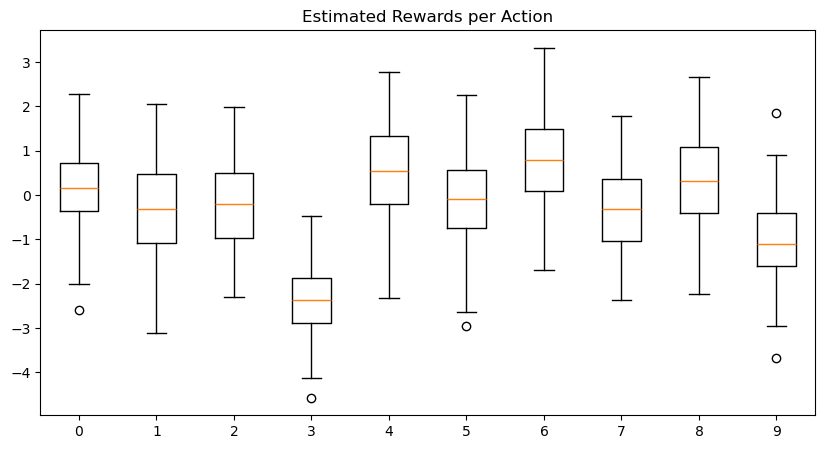

In [6]:
plt.figure(figsize=(10, 5))
plt.boxplot(rewards_per_action, tick_labels=labels)
plt.title('Estimated Rewards per Action')
plt.show()

¿Coincide con el valor verdadero de cada brazo ($q_*(a)$)?

100%|██████████| 2000/2000 [00:04<00:00, 447.63it/s]


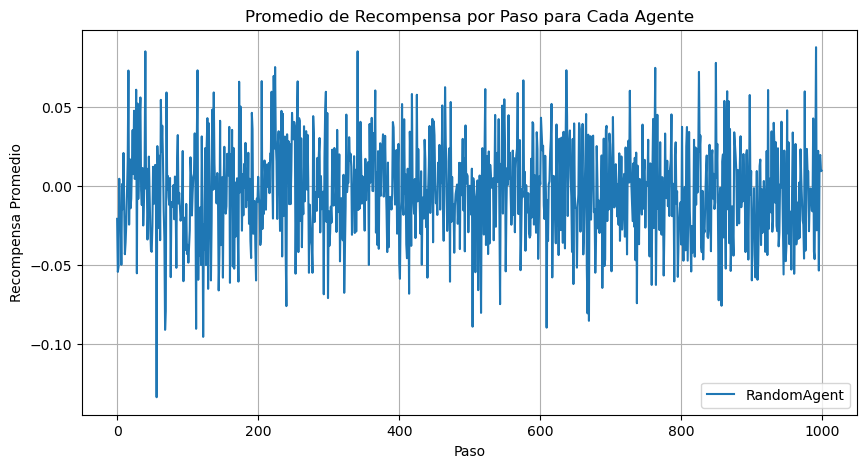

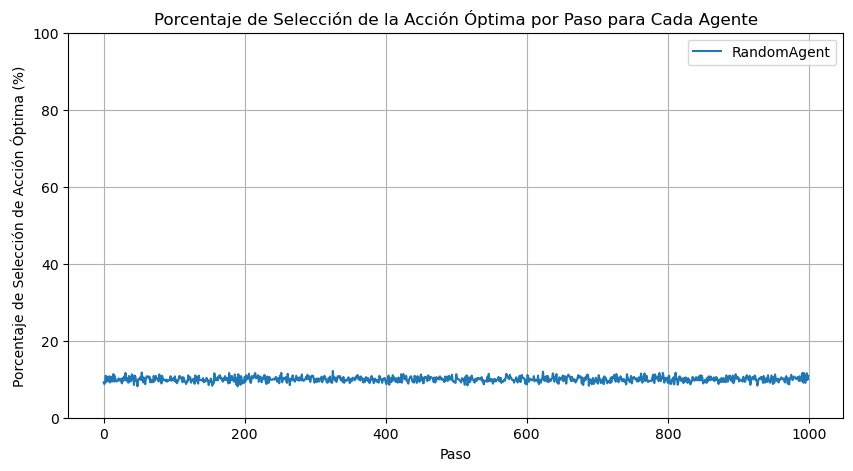

In [7]:
plot_agents_performance([RandomAgent("RandomAgent")], num_steps=NUM_STEPS, num_episodes=NUM_EPISODES)

### Agente epsilon-greedy

El agentes epsilon-greedy es una estrategia simple que selecciona la mejor acción con probabilidad $1-\varepsilon$ y una acción aleatoria con probabilidad $\varepsilon$.

**Initialize, for** $a = 1$ to $k$:

$$
Q(a) \gets 0
$$

$$
N(a) \gets 0
$$

**Loop forever:**

$$
A \gets 
\begin{cases} 
\arg\max_a Q(a) & \text{with probability } 1 - \varepsilon \quad \text{(breaking ties randomly)} \\
\text{a random action} & \text{with probability } \varepsilon
\end{cases}
$$

$$
R \gets \text{bandit}(A)
$$

$$
N(A) \gets N(A) + 1
$$

$$
Q(A) \gets Q(A) + \frac{1}{N(A)} \left[ R - Q(A) \right]
$$

> **Nota sobre el desempate en $\arg\max$:** El pseudocódigo indica *"breaking ties randomly"*. Una alternativa sencilla es usar `np.argmax(Q)`, pero hay que tener en cuenta que esta función siempre retorna el **primer** índice con valor máximo. Esto introduce un sesgo: cuando todos los $Q(a) = 0$ al inicio, el agente siempre elegirá la acción 0 en vez de explorar uniformemente. Para una implementación más fiel al libro, se recomienda seleccionar al azar entre todas las acciones que comparten el valor máximo. Esto aplica a todos los agentes que usen $\arg\max$ (epsilon-greedy, optimista y UCB).

In [8]:
class EpsilonGreedyAgent(Agent):
    def __init__(self, name, epsilon):
        super().__init__(name)
        self.epsilon = epsilon
#        raise NotImplementedError("Implementar constructor")

    def reset_internal_state(self):
        self.q_a = np.zeros(self.environment.action_space.n)
        self.n_a = np.zeros(self.environment.action_space.n)
#        raise NotImplementedError("Implementar reset del estado interno")

    def select_action(self, obs, info):
        if random.random() < self.epsilon:
            return self.environment.action_space.sample() # exploración
        else:
            return np.argmax(self.q_a) # greedy ó exlotación
#        raise NotImplementedError("Implementar selección de acción")
   
    def update_internal_state(self, observation, action, reward, info):
        self.n_a[action] += 1
        self.q_a[action] += (reward - self.q_a[action])/self.n_a[action] 
#        raise NotImplementedError("Implementar actualización del estado interno")
    
    def get_extra_info(self):
        return {
            "n_a": self.n_a,
            "q_a": self.q_a
        }
#        raise NotImplementedError("Implementar información extra")


epsilon_greedy_agent = EpsilonGreedyAgent("EpsilonGreedyAgent", 0.1)

logs, info = epsilon_greedy_agent.play(n_steps = 1000, environment =sample_env)

print(info['n_a'])
print(info['q_a'])
print (f"Accumulated reward: {sum(logs['rewards']):.2f}")
print (f"Mean reward: {logs['rewards'].mean():.2f}")

[ 10.   9.  14.   6. 381.   9. 440.   7. 116.   8.]
[ 0.23570269 -0.75397312 -0.23728308 -2.34794544  0.35993985 -0.3360681
  0.81365621 -0.09942566  0.59265474 -1.33313728]
Accumulated reward: 527.67
Mean reward: 0.53


100%|██████████| 2000/2000 [00:05<00:00, 390.43it/s]


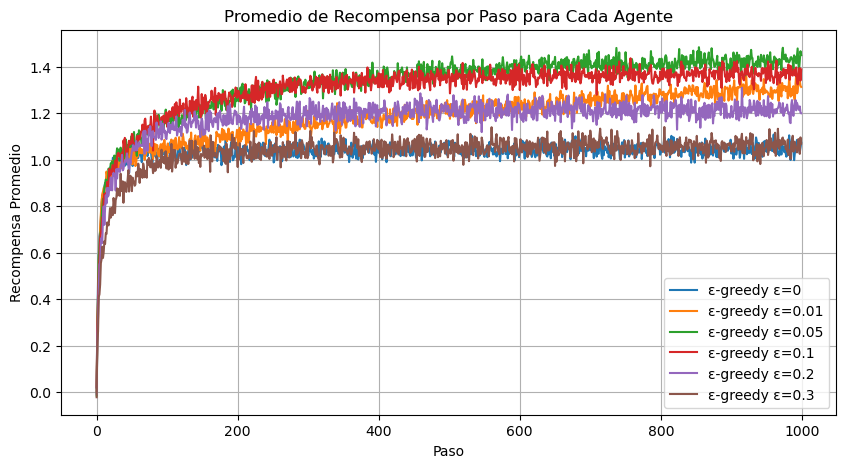

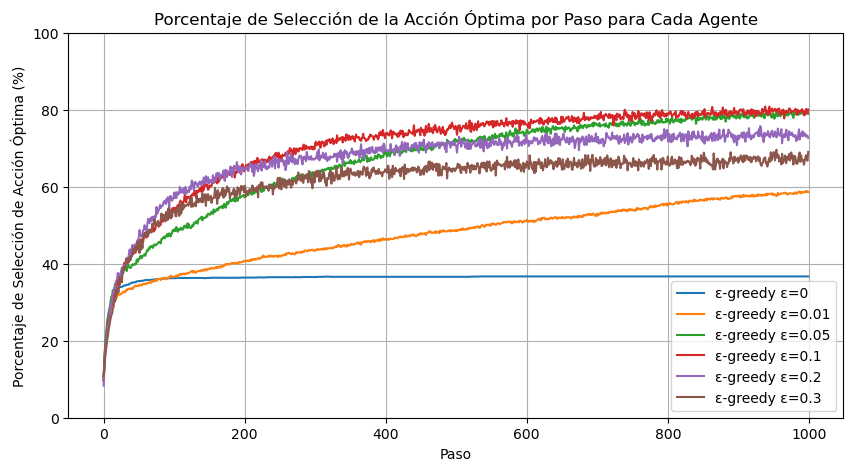

In [9]:
# Comparación con varios ε: trade-off exploración / explotación
EPSILONS = [0, 0.01, 0.05, 0.1, 0.2, 0.3]
plot_agents_performance(
    [
        EpsilonGreedyAgent(f"ε-greedy ε={eps}", eps)
        for eps in EPSILONS
    ],
    num_steps=NUM_STEPS,
    num_episodes=NUM_EPISODES,
)

> Sugerencia:
> - Probar con otros valores de $\epsilon$ y comparar el rendimiento de los agentes. ¿Cómo afecta el valor de $\epsilon$ al rendimiento del agente?
> - ¿Qué ocurre si incrementamos la cantidad de pasos de entrenamiento? ¿Cómo afecta esto al rendimiento de los agentes?
>
>```python
>plot_agents_performance([
>    EpsilonGreedyAgent("EpsilonGreedyAgent e=a", a),
>    EpsilonGreedyAgent("EpsilonGreedyAgent e=b", b),
>    ...
>    EpsilonGreedyAgent("EpsilonGreedyAgent e=z", z)
>    ], num_steps=NUM_STEPS, num_episodes=NUM_EPISODES)
>```

### Probar con otros valores de $\epsilon$ y comparar el rendimiento de los agentes. ¿Cómo afecta el valor de $\epsilon$ al rendimiento del agente?


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:04<00:00, 400.57it/s]


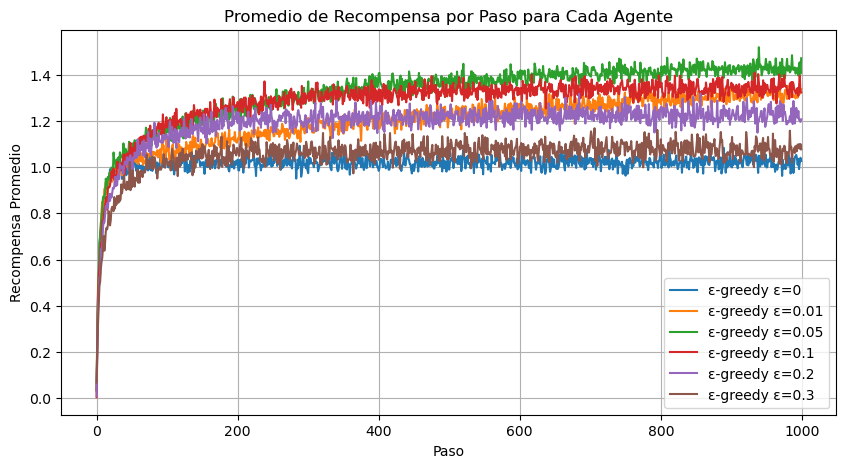

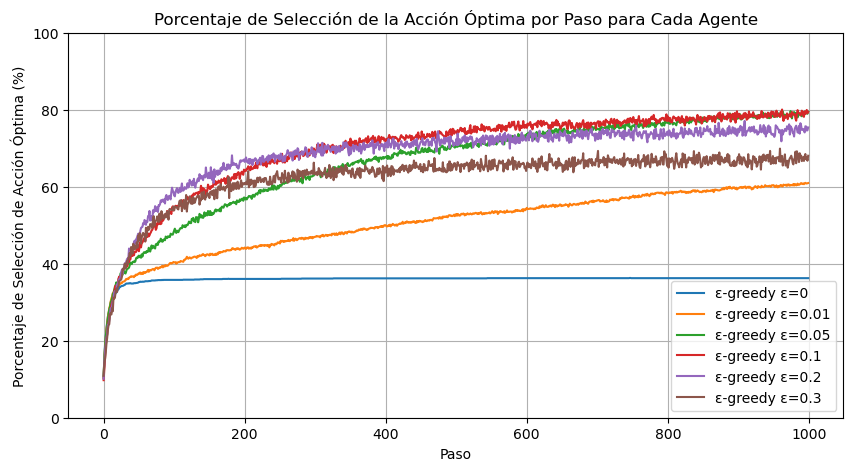

In [10]:
EPSILONS = [0, 0.01, 0.05, 0.1, 0.2, 0.3]
plot_agents_performance(
    [
        EpsilonGreedyAgent(f"ε-greedy ε={eps}", eps)
        for eps in EPSILONS
    ],
    num_steps=NUM_STEPS,
    num_episodes=NUM_EPISODES,
)

**¿Cómo afecta $\epsilon$ al rendimiento?** 
- **$\epsilon$ grande** (p. ej. 0.2–0.3): más exploración; la recompensa promedio suele subir rápido al principio porque prueba más brazos, pero en el largo plazo sigue perdiendo una fracción $\epsilon$ de pasos en acciones subóptimas, así que el % de acción óptima suele estabilizarse por debajo del máximo posible y la recompensa media puede quedar limitada.

- **$\epsilon$ pequeño** (p. ej. 0.01): menos exploración; puede tardar más en encontrar el mejor brazo (riesgo de quedarse con uno malo), pero si ya lo identifica, en el largo plazo obtiene mejor recompensa media y mayor % óptimo que con $\epsilon$ alto.

### ¿Qué ocurre si incrementamos la cantidad de pasos de entrenamiento? ¿Cómo afecta esto al rendimiento de los agentes?


Evaluando con num_steps = 2000


100%|██████████| 1000/1000 [00:04<00:00, 202.68it/s]


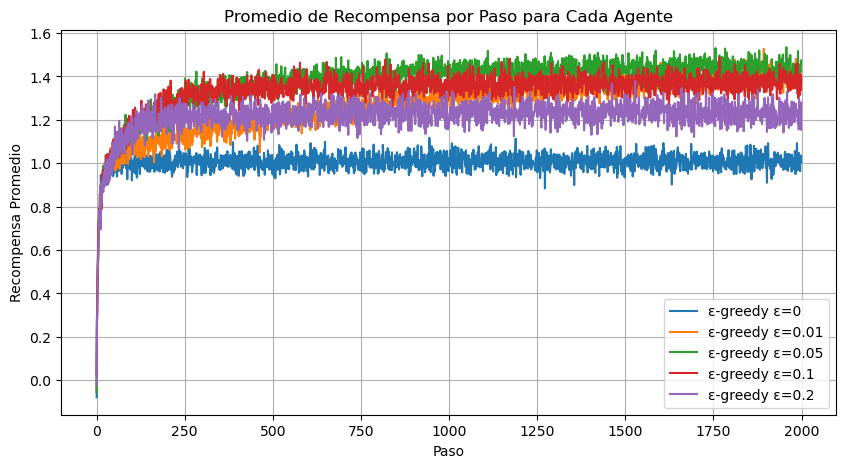

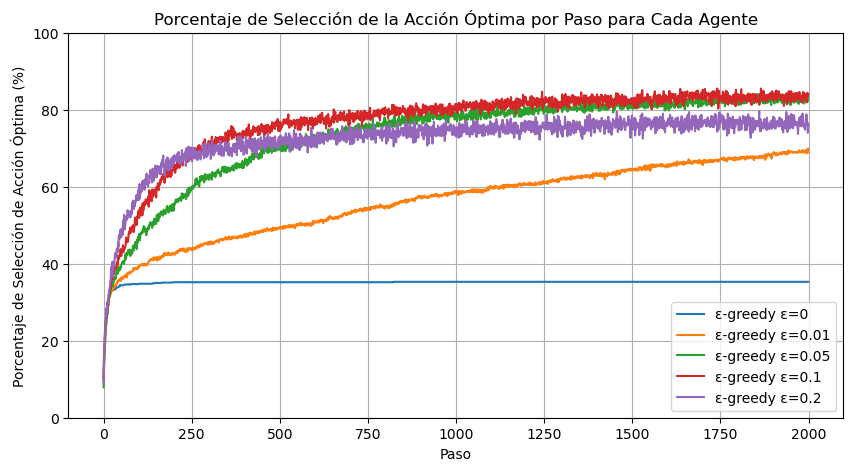

Evaluando con num_steps = 3000


100%|██████████| 1000/1000 [00:08<00:00, 113.78it/s]


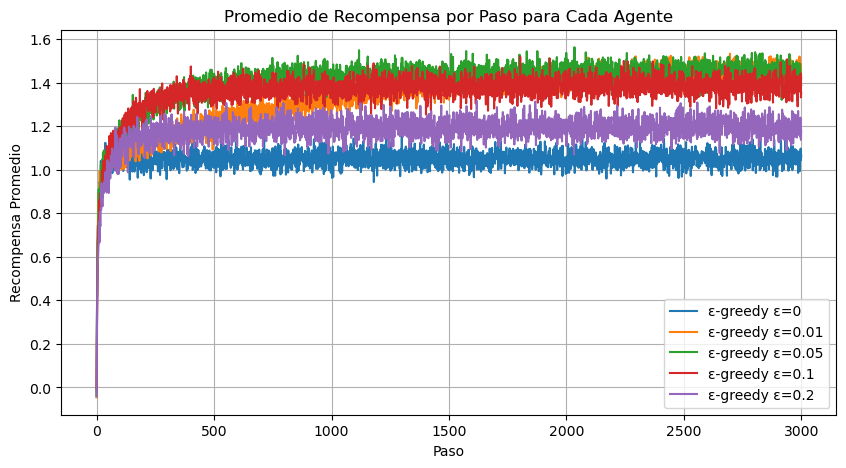

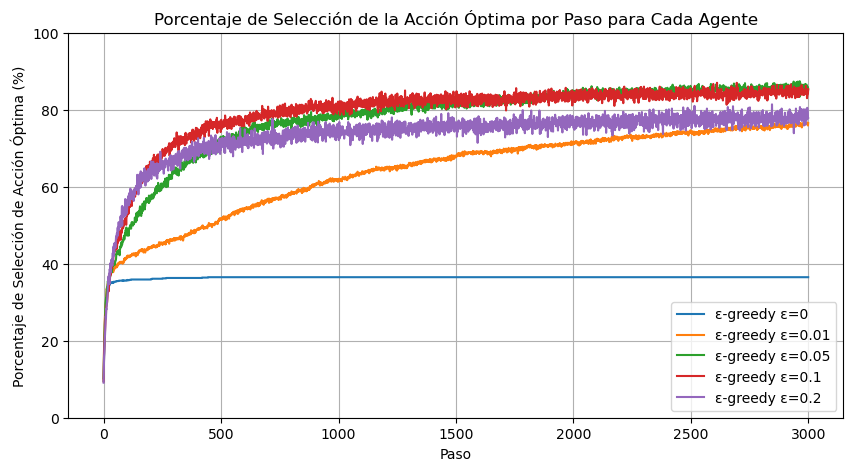

Evaluando con num_steps = 4000


100%|██████████| 1000/1000 [00:10<00:00, 93.14it/s]


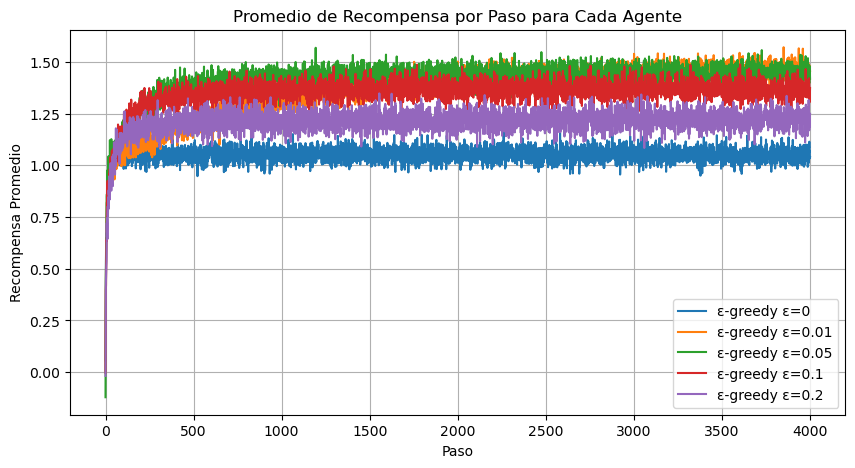

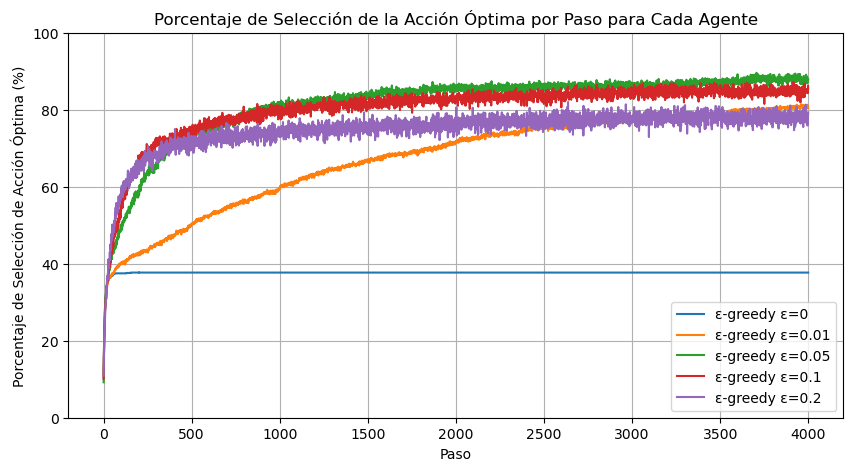

In [11]:
STEP_LIST = [2000, 3000, 4000] 
NUM_EPISODES = 1000 
for n in STEP_LIST:
    print(f"Evaluando con num_steps = {n}")
    plot_agents_performance(
        [
            EpsilonGreedyAgent(f"ε-greedy ε={eps}", eps)
            for eps in [0, 0.01, 0.05, 0.1, 0.2]
        ],
        num_steps=n,
        num_episodes=NUM_EPISODES,
    )

Aumentando la cantidad de steps se ve cómo valores de $\epsilon$ más pequeños tienden a lograr mejores recompensas en en pasos finales. Casos como $\epsilon = 0.05$ son los que más destacan por esto, y en el caso de $\epsilon = 0.01$ seguramente tenga mejores resultados probando con mayor cantidad de steps.  

### Agente epsilon-greedy optimista

El agente epsilon-greedy optimista es una variante del agente epsilon-greedy que inicializa los valores de recompensa estimados ($Q(a)$) con un valor optimista, en lugar de cero. Esto fomenta la exploración de acciones menos conocidas al principio, ya que el agente cree que todas las acciones tienen un valor más alto del que realmente tienen.

Preguntas:
- ¿Qué ocurre si ponemos un valor optimista muy alto?
- ¿Qué ocurre si ponemos un valor optimista muy bajo?

**Initialize, for** $a = 1$ to $k$:

$$
Q(a) \gets q_1
$$

$$
N(a) \gets 0
$$

**Loop forever:**

$$
A \gets 
\begin{cases} 
\arg\max_a Q(a) & \text{with probability } 1 - \varepsilon \quad \text{(breaking ties randomly)} \\
\text{a random action} & \text{with probability } \varepsilon
\end{cases}
$$

$$
R \gets \text{bandit}(A)
$$

$$
N(A) \gets N(A) + 1
$$

$$
Q(A) \gets Q(A) + \alpha (R - Q(A))
$$

> Nota: para esta implementación, usamos $alpha$ en lugar de $\frac{1}{N(A)}$ para actualizar el valor de $Q(A)$. Ver capítulo 2.5 del libro de Sutton y Barto.

In [12]:
class OptimisticEpsilonGreedyAgent(Agent):
    def __init__(self, name, epsilon, q_1, alpha = 0.1):
        super().__init__(name)
        self.epsilon = epsilon
        self.q_1 = q_1
        self.alpha = alpha
        #raise NotImplementedError("Implementar constructor")

    def reset_internal_state(self):
        self.q_a = np.ones(self.environment.action_space.n) * self.q_1
        self.n_a = np.zeros(self.environment.action_space.n)
        #raise NotImplementedError("Implementar reset del estado interno")

    def select_action(self, obs, info):
        if random.random() < self.epsilon: 
            return self.environment.action_space.sample()
        else:
            return np.argmax(self.q_a)
        #raise NotImplementedError("Implementar selección de acción")
   
    def update_internal_state(self, observation, action, reward, info):
        self.n_a[action] += 1
        self.q_a[action] += self.alpha * (reward - self.q_a[action])
        #raise NotImplementedError("Implementar actualización del estado interno")
    
    def get_extra_info(self):
        return {
            "n_a": self.n_a,
            "q_a": self.q_a
        }
        #raise NotImplementedError("Implementar información extra")

# Example run
optimistic_epsilon_greedy_agent = OptimisticEpsilonGreedyAgent("OptimisticEpsilonGreedyAgent", epsilon = 0.1, q_1 = 0)

logs, info = optimistic_epsilon_greedy_agent.play(n_steps = 1000, environment = sample_env)
print(info['n_a'])
print(info['q_a'])
print (f"Accumulated reward: {sum(logs['rewards']):.2f}")
print (f"Mean reward: {logs['rewards'].mean():.2f}")

[  9.   8.   6.   9. 210.  15. 166.  17. 546.  14.]
[-0.04142029 -0.10512007 -0.05968823 -1.75974784 -0.16598558  0.11767255
  1.21122897  0.10346089  0.06445623 -1.0155294 ]
Accumulated reward: 486.04
Mean reward: 0.49


100%|██████████| 1000/1000 [00:02<00:00, 406.18it/s]


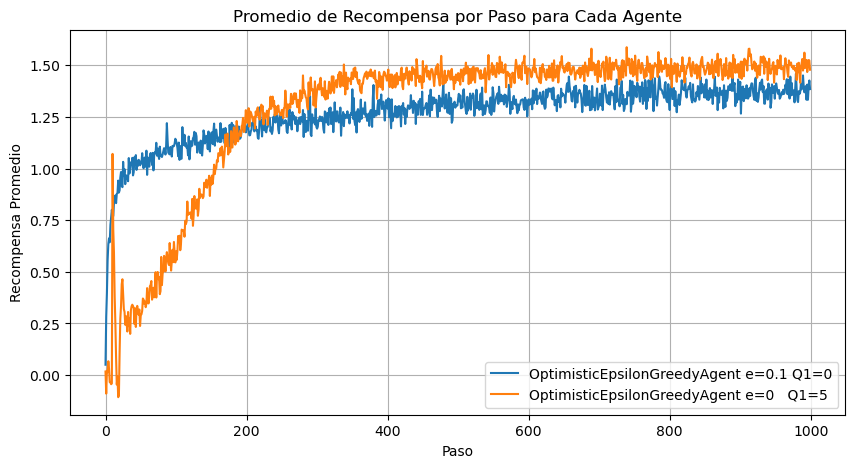

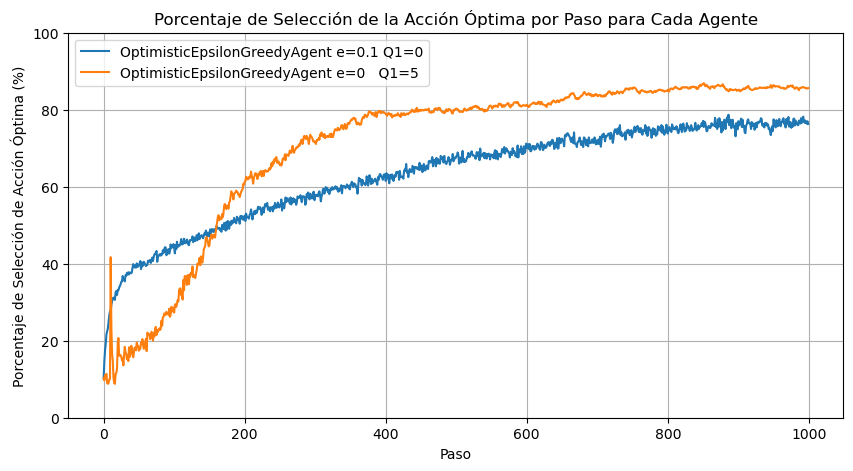

In [13]:
plot_agents_performance([
    OptimisticEpsilonGreedyAgent("OptimisticEpsilonGreedyAgent e=0.1 Q1=0", epsilon = 0.1, q_1 = 0),
    OptimisticEpsilonGreedyAgent("OptimisticEpsilonGreedyAgent e=0   Q1=5", epsilon = 0,   q_1 = 5),
    ], num_steps=NUM_STEPS, num_episodes=NUM_EPISODES)

### ¿Qué ocurre si ponemos un valor optimista muy alto?

100%|██████████| 1000/1000 [00:02<00:00, 393.78it/s]


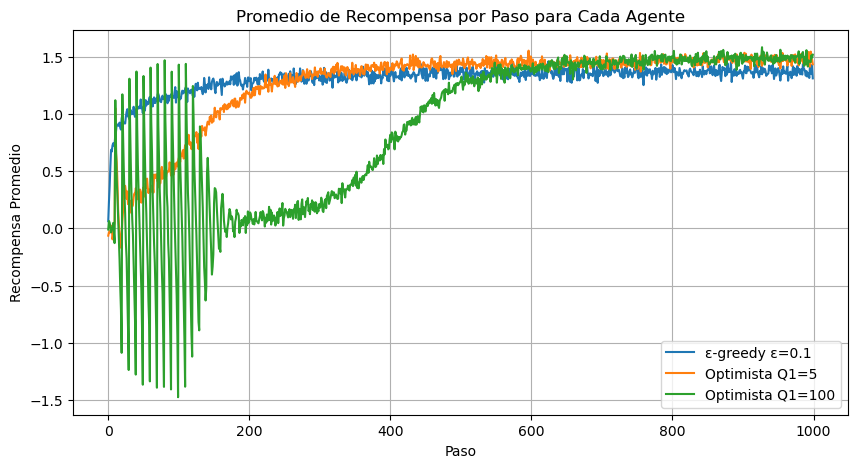

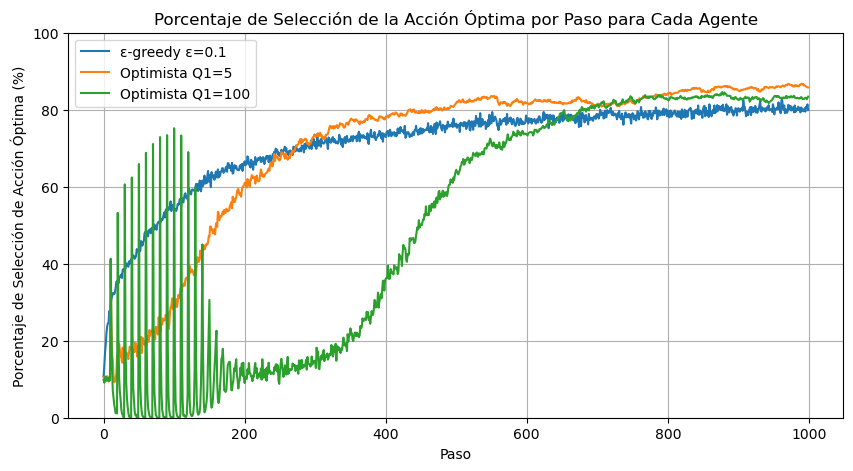

In [14]:
plot_agents_performance(
    [
        EpsilonGreedyAgent("ε-greedy ε=0.1", 0.1),
        OptimisticEpsilonGreedyAgent("Optimista Q1=5", epsilon=0, q_1=5),
        OptimisticEpsilonGreedyAgent("Optimista Q1=100", epsilon=0, q_1=100),
    ],
    num_steps=NUM_STEPS,
    num_episodes=NUM_EPISODES,
)

El agente elige (greedy) cualquier brazo — al inicio todos empatan en 100. Recibe una recompensa real ~1 → Q(A) cae: 100 + 0.1*(1 - 100) ≈ 90.                                

En este punto, el brazo que fue elegido baja su estimación Q a 90, mientras que los demás brazos siguen en 100. Como resultado, el agente elige un brazo distinto la siguiente vez, buscando el que tenga Q alto. Este patrón se repite: cada vez que el agente prueba un nuevo brazo, la recompensa real es mucho menor que la Q inicial, por lo que la estimación Q de ese brazo cae. Así, el agente continúa cambiando de brazo, explorando todos los disponibles, ya que cada uno que prueba "decepciona" y lo impulsa a intentar con otro.

Esto crea exploración sistemática forzada: el agente recorre todos los brazos aunque ε=0.

### ¿Qué ocurre si ponemos un valor optimista muy bajo?

100%|██████████| 1000/1000 [00:02<00:00, 416.64it/s]


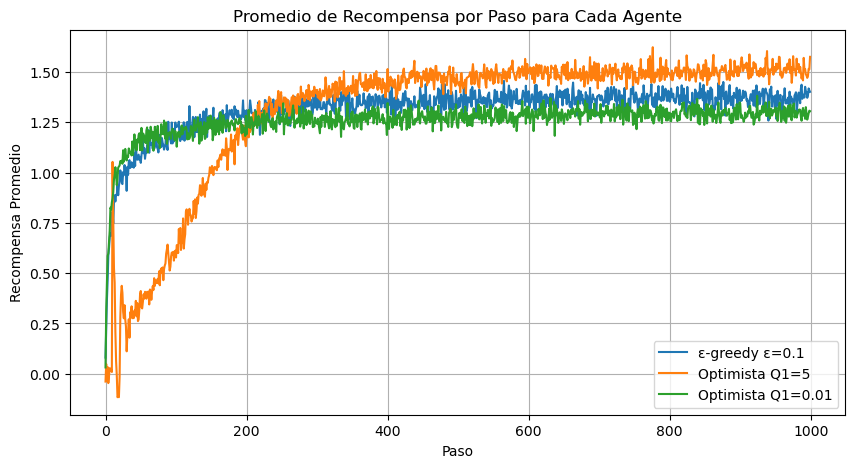

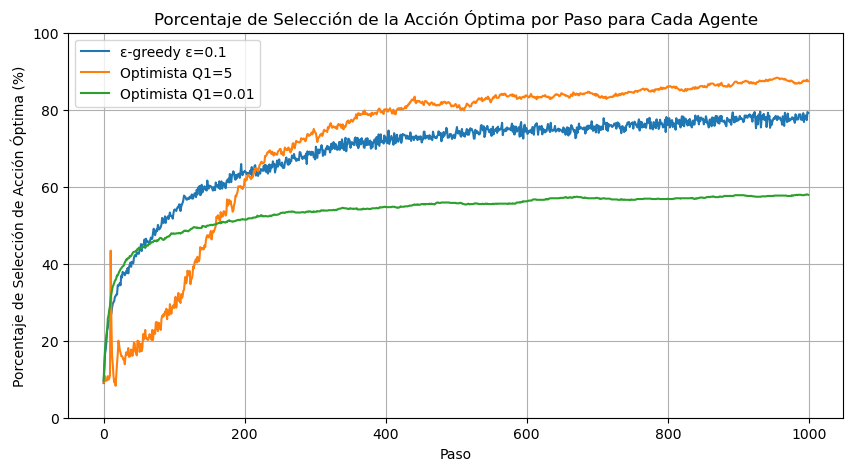

In [15]:
plot_agents_performance(
    [
        EpsilonGreedyAgent("ε-greedy ε=0.1", 0.1),
        OptimisticEpsilonGreedyAgent("Optimista Q1=5", epsilon=0, q_1=5),
        OptimisticEpsilonGreedyAgent("Optimista Q1=0.01", epsilon=0, q_1=0.1),
    ],
    num_steps=NUM_STEPS,
    num_episodes=NUM_EPISODES,
)

Cuando Q₁ es casi nulo o muy bajo en comparación con las medias verdaderas $q^*(a)$ del ambiente las estimaciones iniciales no son “optimistas”: todos los brazos parecen poco atractivos o mediocres desde el inicio.

Por lo tanto, no existe un incentivo fuerte para probar sistemáticamente todos los brazos porque todavía podrían ser poco creibles.

El comportamiento greedy con $\epsilon=0.01$ se basa rápidamente en las primeras recompensas obtenidas y 
se estabiliza pronto en un solo brazo que aparenta ser el mejor.

### Agente Upper Confidence Bound (UCB)

El agente UCB es una estrategia de selección de acciones que equilibra de forma inteligente la exploración y la explotación. En lugar de elegir acciones de forma aleatoria con cierta probabilidad (como en epsilon-greedy), el agente UCB asigna a cada acción una "bonificación de exploración" que disminuye conforme la acción es seleccionada más veces. Esta bonificación se combina con la estimación actual del valor $Q(a)$ para formar un criterio de selección.

Para cada acción $a$, se calcula:

$$
UCB(a) = Q(a) + c \sqrt{\frac{\ln t}{N(a)}}
$$

donde:
- $Q(a)$ es la estimación del valor esperado de la acción $a$.
- $N(a)$ es el número de veces que se ha seleccionado la acción $a$.
- $t$ es el número total de pasos (o iteraciones) realizados hasta el momento.
- $c$ es un parámetro que determina el grado de exploración: un valor mayor favorece la exploración de acciones menos probadas.

**Inicialización:**

Para cada acción $a = 1, \dots, k$:

$$
Q(a) \gets 0
$$
$$
N(a) \gets 0
$$
$$
t \gets 0
$$

**Algoritmo:**

**Loop forever:**

   $$
   t \gets t + 1
   $$

   $$
   A \gets \arg\max_a \left\{ Q(a) + c \sqrt{\frac{\ln t}{N(a)}} \right\}
   $$
   $$
   R \gets \text{bandit}(A)
   $$
   $$
   N(A) \gets N(A) + 1
   $$
   $$
   Q(A) \gets Q(A) + \frac{1}{N(A)} \left( R - Q(A) \right)
   $$
   **Notas:** 
   - Para aquellas acciones que aún no han sido seleccionadas ($N(a) = 0$), se suele asignar un valor infinito al término de exploración para garantizar que cada acción se pruebe al menos una vez.
   - Se puede usar una tasa de aprendizaje $\alpha$ para actualizar $Q(A)$ en lugar de $\frac{1}{N(A)}$.

##### Lectura recomendada:
   https://tor-lattimore.com/downloads/book/book.pdf Cap 7

#### Preguntas:

- **¿Qué sucede si el parámetro $c$ es muy alto?**
- **¿Qué sucede si el parámetro $c$ es muy bajo?**  

In [16]:
class UCBAgent(Agent):
    def __init__(self, name, C):
        super().__init__(name)
        self.C = C
        #raise NotImplementedError("Implementar constructor")

    def reset_internal_state(self):
        self.q_a = np.zeros(self.environment.action_space.n)
        self.n_a = np.ones(self.environment.action_space.n) * 0.000000001
        self.t = np.zeros(self.environment.action_space.n)
        #raise NotImplementedError("Implementar reset del estado interno")

    def select_action(self, obs, info):
        return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
        #raise NotImplementedError("Implementar selección de acción")
        
    def update_internal_state(self, observation, action, reward, info):
        self.t += 1
        self.n_a[action] += 1
        self.q_a[action] += (reward - self.q_a[action]) / self.n_a[action]

        #raise NotImplementedError("Implementar actualización del estado interno")
    
    def get_extra_info(self):
        return {
            "n_a": self.n_a,
            "q_a": self.q_a
        }
        #raise NotImplementedError("Implementar información extra")

# Example run
UCB_agent = UCBAgent("UCBAgent", 1)

logs, info = UCB_agent.play(n_steps = 1000, environment =sample_env)
print(info['n_a'])
print(info['q_a'])
print (f"Accumulated reward: {sum(logs['rewards']):.2f}")
print (f"Mean reward: {logs['rewards'].mean():.2f}")

[  9.   5.   1.   1.   6.   3. 706.   1. 266.   2.]
[-0.21550189 -0.51283719 -2.4649796  -1.9708578  -0.36451433 -0.80694687
  0.72927798 -2.24546253  0.51530043 -1.73495135]
Accumulated reward: 632.68
Mean reward: 0.63


/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: divide by zero encountered in log
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )


  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: divide by zero encountered in log
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
100%|██████████| 1000/1000 [00:02<00:00, 418.31it/s]


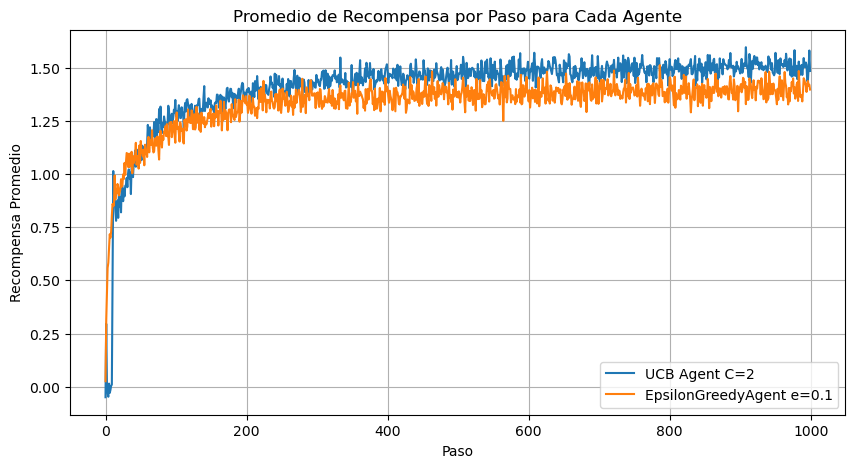

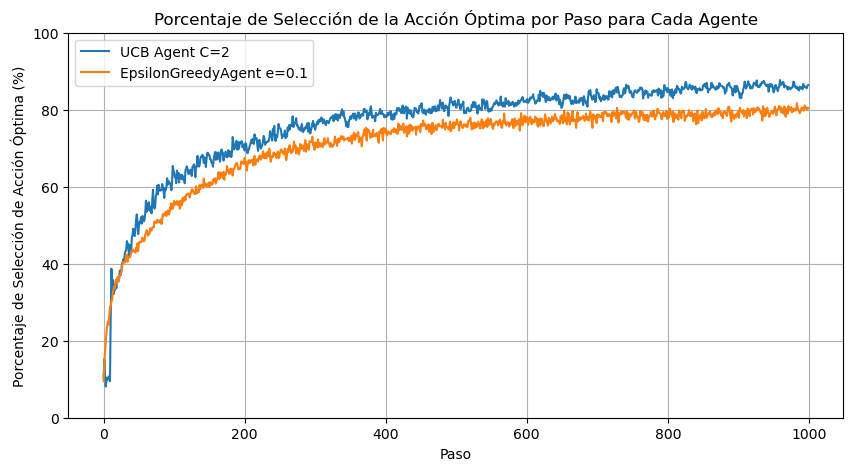

In [17]:
plot_agents_performance([
    UCBAgent("UCB Agent C=2", 2),
    EpsilonGreedyAgent("EpsilonGreedyAgent e=0.1", 0.1),
    ], num_steps=NUM_STEPS, num_episodes=NUM_EPISODES)

### ¿Qué sucede si el parámetro $c$ es muy alto?

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: divide by zero encountered in log
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
100%|██████████| 1000/1000 [00:02<00:00, 409.55it/s]


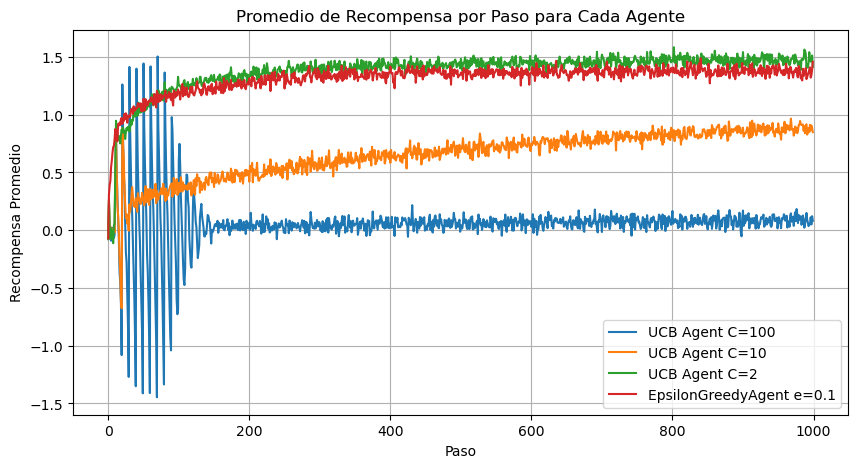

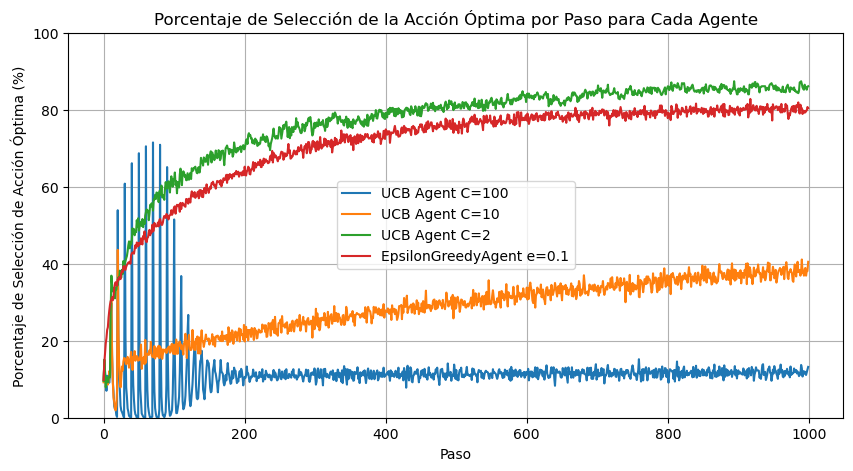

In [18]:
plot_agents_performance([
    UCBAgent("UCB Agent C=100", 100),
    UCBAgent("UCB Agent C=10", 10),
    UCBAgent("UCB Agent C=2", 2),
    EpsilonGreedyAgent("EpsilonGreedyAgent e=0.1", 0.1),
    ], num_steps=NUM_STEPS, num_episodes=NUM_EPISODES)

Un valor de C demasiado alto hace que el agente explore excesivamente, seleccionando con mucha frecuencia acciones subóptimas para “explorar” más, y por tanto podría obtener un rendimiento claramente inferior durante mucho tiempo.

### ¿Qué sucede si el parámetro $c$ es muy bajo?

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: divide by zero encountered in log
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
100%|██████████| 1000/1000 [00:02<00:00, 412.53it/s]


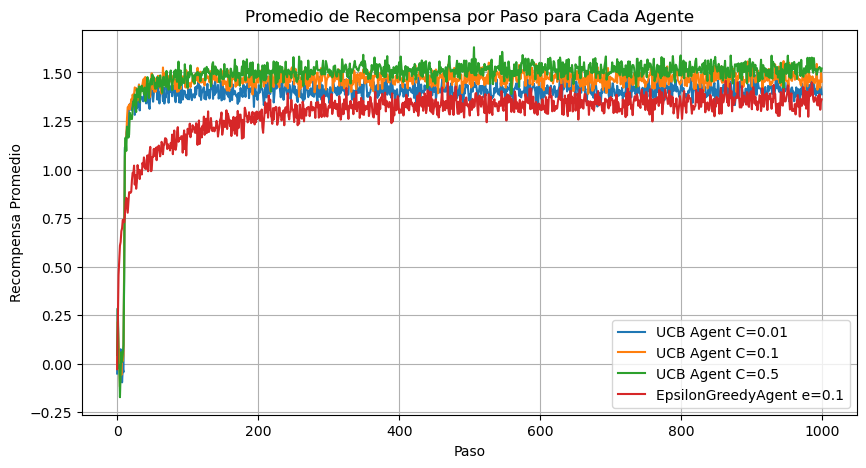

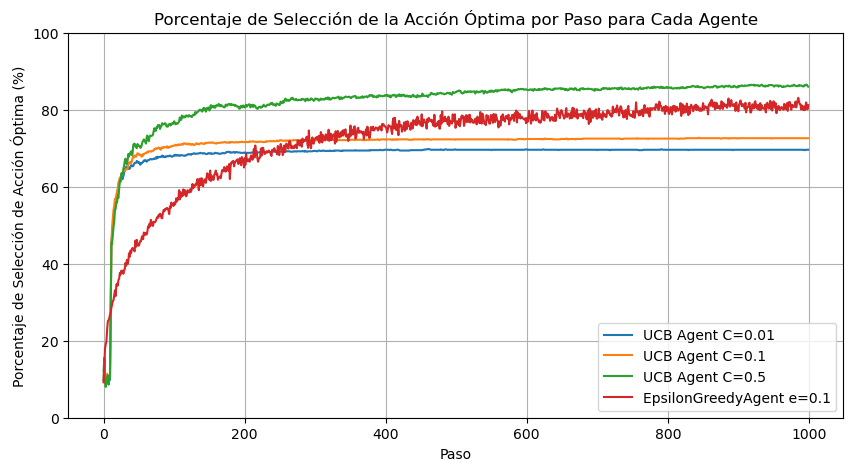

In [19]:
plot_agents_performance([
    UCBAgent("UCB Agent C=0.01", 0.01),
    UCBAgent("UCB Agent C=0.1", 0.1),
    UCBAgent("UCB Agent C=0.5", 0.5),
    EpsilonGreedyAgent("EpsilonGreedyAgent e=0.1", 0.1),
    ], num_steps=NUM_STEPS, num_episodes=NUM_EPISODES)

Si "C" es muy chico, ese sesgo a explorar se vuelve débil y el agente se comporta casi como si siempre eligiera el que hoy le parece mejor según lo poco que vio. Eso hace que aprenda rápido al principio, pero también que se encierre pronto en un brazo que pudo haber salido bien por suerte aunque no sea el mejor de verdad; por eso a largo plazo suele quedar con menos recompensa y elige el óptimo menos veces que si usás un C un poco más grande, que obliga a seguir probando hasta estar más seguros.

## Tareas

1. Implementar los agentes mencionados.
2. Comentar los resultados obtenidos en las gráficas.
3. Seleccionar de cada agente el/los mejores hiperparámetros.
4. Tomar el mejor candidato de cada agente y compararlos en un mismo gráfico.
5. Explique porque en algunos agentes sus graficas tienen picos (epsilon-greedy optimista y UCB).
6. [Extra] Implementar un agente [epsilon-greedy con decay](https://arxiv.org/pdf/1910.13701).

## Epsilon-greedy con decay

Puntos clave de la implementación:
- change = (ε_start - ε_min) / steps_to_decay — calcula el paso de decaimiento (Algorithm 2 del paper)
- El decaimiento ocurre en update_internal_state, no por episodio sino por step, condicionado a que reward >= reward_threshold (Algorithm 3)
- Cada vez que epsilon decae, el umbral sube en reward_increment, haciéndolo cada vez más difícil de alcanzar
- max(epsilon_min, ...) asegura que epsilon no caiga por debajo del mínimo 

In [ ]:
class RBEDEpsilonGreedyAgent(Agent):
    """
    Epsilon-Greedy con Reward Based Epsilon Decay (RBED).
    epsilon solo decae cuando la recompensa supera un umbral creciente,
    en lugar de decaer de forma fija por episodio.
    """
    def __init__(self, name, epsilon_start=1.0, epsilon_min=0.0,
                 reward_threshold_start=0.0, reward_increment=0.1, steps_to_decay=100):
        super().__init__(name)
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.reward_threshold_start = reward_threshold_start
        self.reward_increment = reward_increment
        self.steps_to_decay = steps_to_decay
        self.change = (epsilon_start - epsilon_min) / steps_to_decay  # Alg. 2: change = (epsilon - min)/steps

    def reset_internal_state(self):
        self.q_a = np.zeros(self.environment.action_space.n)
        self.n_a = np.zeros(self.environment.action_space.n)
        self.epsilon = self.epsilon_start
        self.reward_threshold = self.reward_threshold_start

    def select_action(self, obs, info):
        if random.random() < self.epsilon:
            return self.environment.action_space.sample()
        else:
            return np.argmax(self.q_a)

    def update_internal_state(self, observation, action, reward, info):
        # Actualización estándar de Q(a)
        self.n_a[action] += 1
        self.q_a[action] += (reward - self.q_a[action]) / self.n_a[action]

        # RBED (Alg. 3): decae epsilon solo si reward supera el umbral
        if reward >= self.reward_threshold:
            self.epsilon = max(self.epsilon_min, self.epsilon - self.change)
            self.reward_threshold += self.reward_increment

    def get_extra_info(self):
        return {
            "n_a": self.n_a,
            "q_a": self.q_a,
            "epsilon": self.epsilon,
            "reward_threshold": self.reward_threshold,
        }

In [21]:
rbed_agent = RBEDEpsilonGreedyAgent(
    "RBED Agent",
    epsilon_start=1.0,
    epsilon_min=0.01,
    reward_threshold_start=0.0,
    reward_increment=0.1,
    steps_to_decay=100
)

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: divide by zero encountered in log
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
100%|██████████| 1000/1000 [00:02<00:00, 339.29it/s]


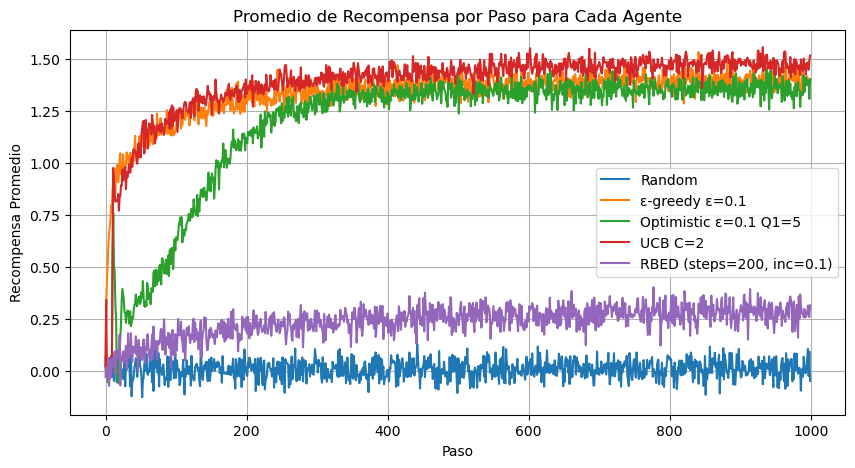

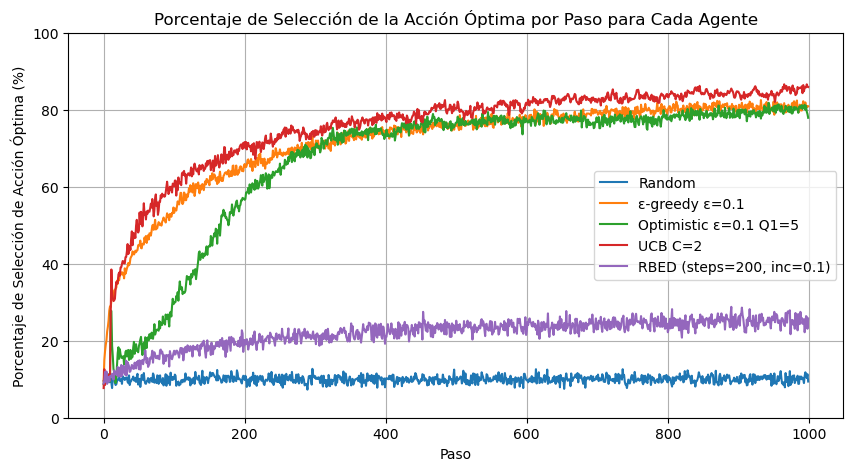

In [24]:
plot_agents_performance(
    [
        # Random baseline
        RandomAgent("Random"),

        # Epsilon-Greedy (sólo una combinación)
        EpsilonGreedyAgent("ε-greedy ε=0.1", 0.1),

        # Optimistic Epsilon-Greedy (sólo una combinación)
        OptimisticEpsilonGreedyAgent("Optimistic ε=0.1 Q1=5", epsilon=0.1, q_1=5),

        # UCB (sólo una combinación)
        UCBAgent("UCB C=2", 2.0),

        # RBED (mejor combinación de hiperparámetros)
        RBEDEpsilonGreedyAgent(
            "RBED (steps=200, inc=0.1)",
            epsilon_start=1.0,
            epsilon_min=0.01,
            reward_threshold_start=0.0,
            reward_increment=0.1,
            steps_to_decay=200,
        ),
    ],
    num_steps=NUM_STEPS,
    num_episodes=NUM_EPISODES
)

100%|██████████| 1000/1000 [00:02<00:00, 360.42it/s]


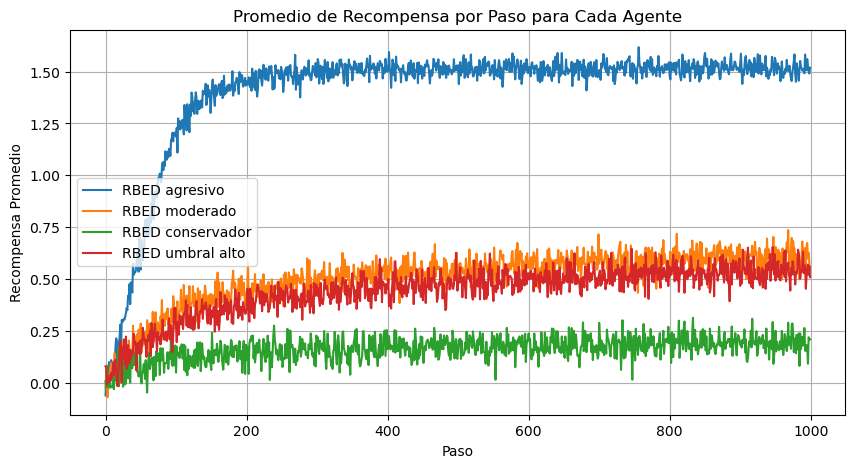

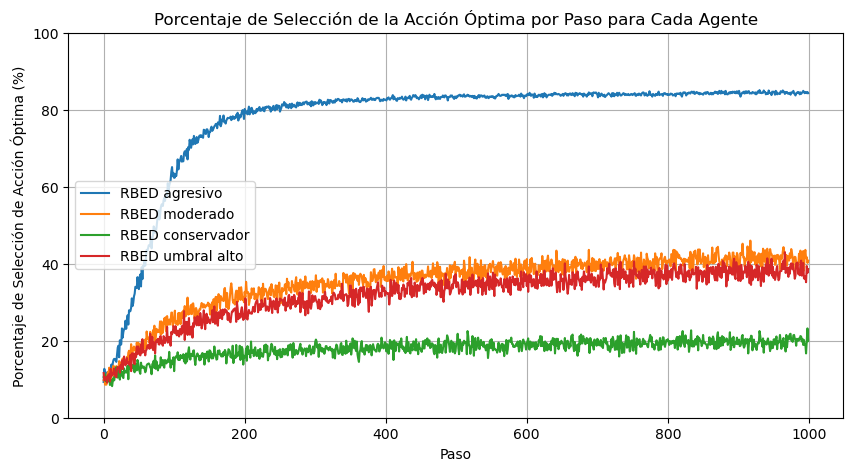

In [ ]:
# 1. Decay agresivo — explota rápido (bueno si el bandit tiene poca varianza)
RBED_agresivo = RBEDEpsilonGreedyAgent(
    "RBED agresivo",
    epsilon_start=1.0,
    epsilon_min=0.01,
    reward_threshold_start=0.0,
    reward_increment=0.05,
    steps_to_decay=50
)

# 2. Decay moderado 
RBED_moderado = RBEDEpsilonGreedyAgent(
    "RBED moderado",
    epsilon_start=1.0,
    epsilon_min=0.01,
    reward_threshold_start=0.0,
    reward_increment=0.1,
    steps_to_decay=100
)

# 3. Decay conservador — explora más (mejor si las recompensas son ruidosas)
RBED_conservador = RBEDEpsilonGreedyAgent(
    "RBED conservador",
    epsilon_start=1.0,
    epsilon_min=0.05,
    reward_threshold_start=0.0,
    reward_increment=0.15,
    steps_to_decay=200
)

# 4. Umbral inicial más alto — fuerza exploración al principio antes de empezar a decaer
RBED_umbral_alto = RBEDEpsilonGreedyAgent(
    "RBED umbral alto",
    epsilon_start=1.0,
    epsilon_min=0.01,
    reward_threshold_start=0.5,
    reward_increment=0.1,
    steps_to_decay=100
)

plot_agents_performance(
    [
        RBED_agresivo,
        RBED_moderado,
        RBED_conservador,
        RBED_umbral_alto,
    ],
    num_steps=NUM_STEPS,
    num_episodes=NUM_EPISODES
)

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: divide by zero encountered in log
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
/var/folders/_q/twq0th115qx2v66s9dcxxpp40000gn/T/ipykernel_28716/3397202794.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.argmax( self.q_a + self.C * np.sqrt( np.log(self.t) / self.n_a) )
100%|██████████| 1000/1000 [00:02<00:00, 413.10it/s]


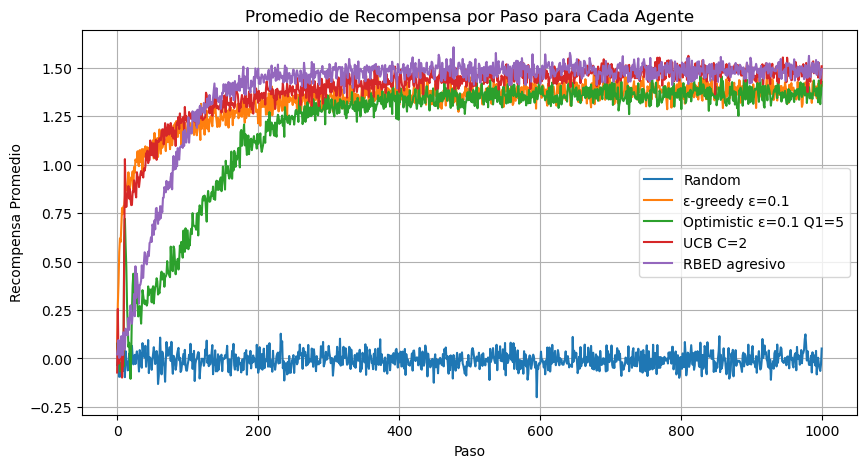

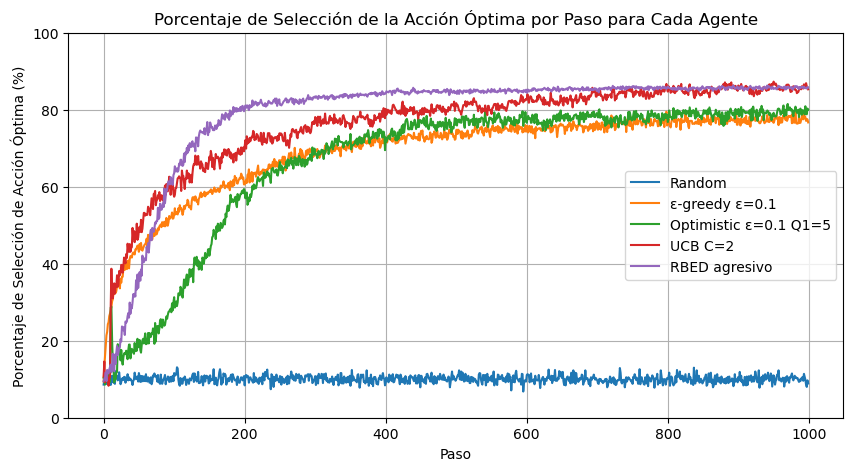

In [ ]:
plot_agents_performance(
    [
        RandomAgent("Random"),

        EpsilonGreedyAgent("ε-greedy ε=0.1", 0.1),

        OptimisticEpsilonGreedyAgent("Optimistic ε=0.1 Q1=5", epsilon=0.1, q_1=5),

        UCBAgent("UCB C=2", 2.0),

        RBEDEpsilonGreedyAgent(
            "RBED agresivo",
            epsilon_start=1.0,
            epsilon_min=0.01,
            reward_threshold_start=0.0,
            reward_increment=0.05,
            steps_to_decay=50
        ),
    ],
    num_steps=NUM_STEPS,
    num_episodes=NUM_EPISODES
)

- Random: no aprende; la media se queda cerca de la recompensa esperada al elegir al azar.

- ε-greedy con ε = 0.1: aprende rápido al principio porque explora mucho y pronto identifica brazos mejores, luego se estabiliza. Aunque ya “sabe” el mejor brazo, sigue perdiendo rendimiento por esa exploración fija.

- Optimista (Q₁ = 5) con ε = 0.1: al sobreestimar al inicio, al principio explora más, por eso sube más lento que ε-greedy. Con el tiempo converge a un nivel parecido al ε-greedy porque el ε fijo sigue imponiendo un techo parecido en explotación pura.

- UCB (C = 2): la exploración depende de la incertidumbre (brazos poco probados siguen siendo atractivos). Es eficiente al inicio y supera un poco a ε-greedy porque la exploración no es un porcentaje fijo al azar y tiende a reducirse cuando la incertidumbre baja.

- RBED: este diseño implica una exploración que decae con el tiempo (o un criterio más “agresivo” para pasar a explotar). Al principio puede subir menos que ε-greedy ó UCB si explora de forma más controlada, pero a largo plazo puede acercarse a casi siempre elegir el mejor brazo, sin el “impuesto permanente” del ε constante ni una fase optimista tan larga.